# Example 20: Generating layers with `LayerFactory`

This example demonstrates `pystrata.factories.LayerFactory`, which builds a
stack of `Layer` objects whose shear-wave velocity follows a simple
power-law model:

$$V_s(x) = \text{coef} \cdot x^{\text{power}}$$

where $x$ is either depth or mean effective stress. Rather than specifying
layer thicknesses directly, you specify a total thickness for a *span* and a
`count` of sub-layers; the span is partitioned so that **each sub-layer has
the same travel time** ($\text{thickness} / V_s$), which naturally produces
thin layers where velocity is low (near the surface) and thicker layers
where velocity is high (at depth).

For each sub-layer, the mean effective stress at its midpoint is computed
(accounting for the water table) and passed to the soil type
(e.g. `darendeli_soil_type`, `menq_soil_type`) so its nonlinear modulus
reduction/damping curves are initialized appropriately.

## Key features shown here

Building a layered profile with **one `LayerFactory`** and **multiple
`add()` calls** ("spans"), each with its own unit weight, power-law
coefficients, soil type, and driving parameter (`"depth"` or
`"mean_eff_stress"`).


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pystrata
from pystrata.factories import LayerFactory, darendeli_soil_type, menq_soil_type
from pystrata.site import Profile

%matplotlib inline

In [2]:
# Increased figure sizes
plt.rcParams["figure.dpi"] = 120

## Build a stack with one `LayerFactory`

We create a single factory with a water table 4 m below the ground surface.
The first span models a 12 m fine-grained (clay) unit with velocity driven
by *mean effective stress*, using `darendeli_soil_type`. The second span
models a 18 m gravelly unit below it, with velocity driven by *depth*, using
`menq_soil_type`. Because both spans are added to the *same* factory, depth
and stress are tracked continuously between them -- the second span picks
up exactly where the first one left off.

In [3]:
factory = LayerFactory(wt_depth=4.0)

# Span 1: fine-grained soil, velocity driven by mean effective stress
clay_layers = factory.add(
    thickness=12.0,
    unit_wt=18.0,
    coef=110,
    power=0.22,
    param="mean_eff_stress",
    count=8,
    soil_type=darendeli_soil_type,
    soil_type_kwds={"plas_index": 15, "ocr": 1.2},
)

# Span 2: gravelly soil, velocity driven by depth
gravel_layers = factory.add(
    thickness=18.0,
    unit_wt=20.0,
    coef=180,
    power=0.30,
    param="depth",
    count=10,
    soil_type=menq_soil_type,
    soil_type_kwds={"coef_unif": 8, "diam_mean": 15},
)

print(f"Span 1: {len(clay_layers)} layers, total thickness "
      f"{sum(l.thickness for l in clay_layers):.1f} m")
print(f"Span 2: {len(gravel_layers)} layers, total thickness "
      f"{sum(l.thickness for l in gravel_layers):.1f} m")
print(f"Factory now at depth={factory.depth:.1f} m, "
      f"mean_eff_stress={factory.stress_mean:.1f} kN/m^2")

Span 1: 8 layers, total thickness 12.0 m
Span 2: 10 layers, total thickness 18.0 m
Factory now at depth=30.0 m, mean_eff_stress=214.0 kN/m^2


### Inspect the generated layers

Note how sub-layer thickness grows with depth: equal travel time means
thinner layers where velocity is low (shallow) and thicker layers where
velocity is high (deep).

In [4]:
profile = Profile(factory.layers)

df = profile.to_dataframe()
df 

,soil_type,unit_wt,damping,thickness,shear_vel,depth
0,"Darendeli (PI=15, OCR=1.2, σₘ'=5.2 kN/m²)",18.0,<pystrata.site.DampingCurve object at 0x70bf27...,0.874132,158.391876,0.000000
1,"Darendeli (PI=15, OCR=1.2, σₘ'=18.0 kN/m²)",18.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.251622,207.753807,0.874132
2,"Darendeli (PI=15, OCR=1.2, σₘ'=34.2 kN/m²)",18.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.449204,239.271159,2.125754
3,"Darendeli (PI=15, OCR=1.2, σₘ'=50.0 kN/m²)",18.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.576566,260.097219,3.574958
4,"Darendeli (PI=15, OCR=1.2, σₘ'=58.8 kN/m²)",18.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.636822,269.520045,5.151524
5,"Darendeli (PI=15, OCR=1.2, σₘ'=67.8 kN/m²)",18.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.689504,278.180296,6.788345
6,"Darendeli (PI=15, OCR=1.2, σₘ'=77.2 kN/m²)",18.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.738305,286.204609,8.477849
7,"Darendeli (PI=15, OCR=1.2, σₘ'=86.8 kN/m²)",18.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.783846,293.694364,10.216154
8,"Menq (Cᵤ=8.0, D₅₀=15.0 mm, σₘ'=97.0 kN/m²)",20.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.570598,386.621294,12.000000
9,"Menq (Cᵤ=8.0, D₅₀=15.0 mm, σₘ'=107.9 kN/m²)",20.0,<pystrata.site.DampingCurve object at 0x70bf27...,1.627172,400.532786,13.570598


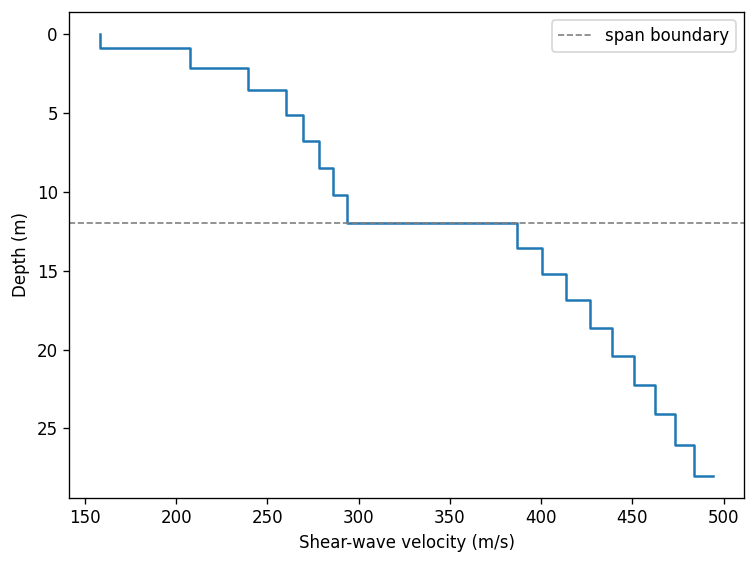

In [5]:
fig, ax = plt.subplots()
ax.step(df["shear_vel"], df['depth'], where="pre")
ax.axhline(12.0, color="gray", ls="--", lw=1, label="span boundary")
ax.invert_yaxis()
ax.set(xlabel="Shear-wave velocity (m/s)", ylabel="Depth (m)")
ax.legend()
fig.tight_layout();

## Use the profile in an analysis

The profile behaves like any other `Profile` -- a bedrock half-space is
added and it can be used directly with pystrata's calculators.

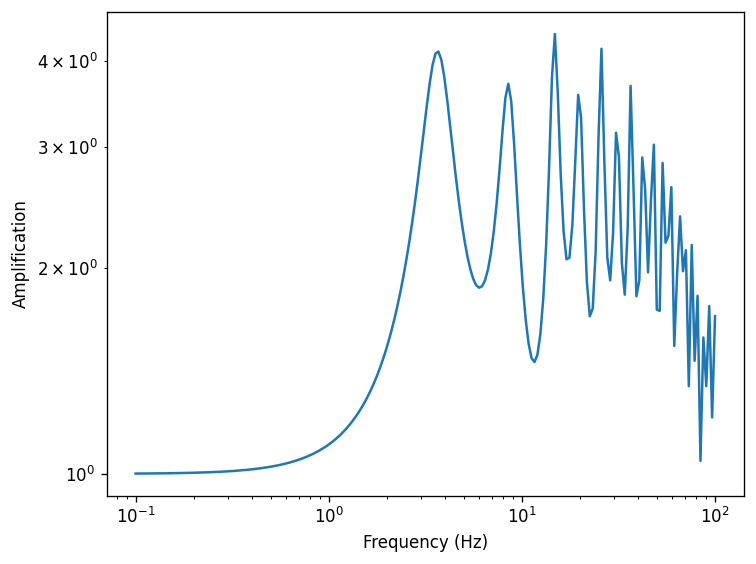

In [6]:
profile.append(
    pystrata.site.Layer(pystrata.site.SoilType("Bedrock", 22.0, None, 0.01), 0, 1200)
)

# A simple flat-spectrum motion is enough to illustrate the site amplification
# from the profile built above.
freqs = np.logspace(-1, 2, num=200)
m = pystrata.motion.RvtMotion(freqs, np.ones_like(freqs), duration=10.0)

calc = pystrata.propagation.LinearElasticCalculator()
loc_in = profile.location("outcrop", index=-1)
loc_out = profile.location("outcrop", index=0)

calc(m, profile, loc_in)
tf = calc.calc_accel_tf(loc_in, loc_out)

fig, ax = plt.subplots()
ax.plot(freqs, np.abs(tf))
ax.set(
    xlabel="Frequency (Hz)",
    xscale="log",
    ylabel="Amplification",
    yscale="log",
)
fig.tight_layout();